# Dự đoán hành khách có khả năng sống soát trong vụ đắm tàu titanic bằng cách áp dụng mô hình máy học

## I. Về tập dữ liệu

### 1. Giới thiệu

Dữ liệu ghi lại thông tin chi tiết về các hành khách trên con tàu RMS Titanic, con tàu bị chìm vào năm 1912 sau khi va chạm với tảng băng trôi. Mục tiêu của bài toán là dự đoán khả năng sống sót của hành khách dựa trên các đặc điểm cá nhân và thông tin hành trình.

### 2. Các biến trong bộ dữ liệu

* **PassengerId**: Mã định danh của hành khách.
* **Survived**: Trạng thái sống sót (0 = Không sống sót, 1 = Sống sót).
* **Pclass**: Hạng vé (1 = Hạng nhất, 2 = Hạng hai, 3 = Hạng ba).
* **Name**: Họ và tên của hành khách.
* **Sex**: Giới tính của hành khách.
* **Age**: Tuổi của hành khách.
* **SibSp**: Số anh/chị/em hoặc vợ/chồng đi cùng.
* **Parch**: Số cha/mẹ hoặc con đi cùng.
* **Ticket**: Số hiệu vé.
* **Fare**: Giá vé mà hành khách đã trả.
* **Cabin**: Số phòng hoặc khoang hành khách.
* **Embarked**: Cảng lên tàu (C = Cherbourg, Q = Queenstown, S = Southampton).

Nguồn: [Titanic Dataset](https://www.kaggle.com/code/alexisbcook/titanic-tutorial/input?select=train.csv) trên Kaggle

## II. Phân tích dữ liệu khám phá

### 1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

### 2. Thống kê mô tả

Đọc dữ liệu

In [2]:
df = pd.read_csv("./data/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Thông tin tập dữ liệu

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Nhận xét**
- Dữ liệu chứa 891 quan sát (mỗi hàng là một hành khách) và 12 biến (mỗi cột là một đặc trưng của hành khách).
- Bộ dữ liệu nhìn chung khá là đầy đủ tuy nhiên vẫn có vài cột bị thiếu:
    - **Age** và **Cabin** có nhiều giá trị bị thiếu.
    - **Embarked** chỉ thiếu 2 giá trị.
- **Pclass** nên được chuyển sang kiểu categorical để phản ánh đúng bản chất.

Thống kê mô tả

In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Nhận xét**

* **PassengerId**: chạy từ 1 đến 891, dùng để định danh, không mang ý nghĩa phân tích.

* **Survived**:

  * Trung bình = **0.384**, tức khoảng **38.4% hành khách sống sót**.
  * Phân phối nhị phân (0 hoặc 1), độ lệch chuẩn ~0.49 phản ánh sự chia tách giữa hai nhóm.

* **Pclass**:

  * Trung bình = **2.31**, cho thấy phần lớn hành khách ở **hạng 2 và 3**.
  * Min = 1, Max = 3 → đúng với ba hạng vé.

* **Age**:

  * Có **714 giá trị hợp lệ**, tức còn **177 giá trị thiếu**.
  * Tuổi trung bình ≈ **29.7**, độ lệch chuẩn ≈ **14.5**, dao động từ **0.42 đến 80 tuổi**.
  * Tứ phân vị: 25% = 20 tuổi, 50% = 28 tuổi, 75% = 38 tuổi → đa số hành khách là **người trưởng thành trẻ**.

* **SibSp** (số anh/chị/em hoặc vợ/chồng đi cùng):

  * Trung bình = **0.52**, hầu hết hành khách **đi một mình hoặc với 1 người**.
  * Max = 8 → có vài trường hợp đi theo nhóm lớn (ngoại lệ).

* **Parch** (số cha/mẹ hoặc con đi cùng):

  * Trung bình = **0.38**, đa phần **không có người thân đi cùng**.
  * Max = 6 → một vài gia đình lớn.

* **Fare** (giá vé):

  * Trung bình ≈ **32.2**, độ lệch chuẩn cao (**49.7**) → **chênh lệch lớn giữa các hạng vé**.
  * Giá vé dao động từ **0 đến 512.33**, phản ánh sự khác biệt rõ giữa hạng 1, 2, và 3.

* Dữ liệu có sự phân tán rõ rệt ở các biến **Fare**, **Age** và **SibSp**, cho thấy có những giá trị ngoại lệ (outliers).

### 3. Tiền xử lí dữ liệu

#### 3.1 Xử lí giá trị trùng lắp

In [5]:
def handle_duplicate(df):
    duplicate_rows = df[df.duplicated()]

    if not duplicate_rows.empty:
        print("\nDuplicated Rows:")
        print(duplicate_rows)
        print(f"\nNumber of Duplicated Rows: {len(duplicate_rows)}")
        df.drop_duplicates()       
    else:
        print("\nNo duplicated rows found.")

#### 3.2 Xử lí giá trị bị thiếu

In [6]:
def handle_missing_data(df):
    # Embarked: chỉ thiếu 2 giá trị -> điền bằng mode
    df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

    # Age: điền bằng median (không nhạy cảm với outliers)
    df["Age"].fillna(df["Age"].median(), inplace=True)

    # Cabin: nhiều missing,  điền 'U' chounknown
    df["Cabin"] = df["Cabin"].fillna("U")


#### 3.3 Tạo các đặc trưng mới

In [7]:
def create_new_features(df):
    
    df["Deck"] = df["Cabin"].str[0]  # A, B, C, ... hoặc 'U'

    # Trích xuất danh xưng từ Name (ví dụ: Mr, Mrs, Miss, Master, ...)
    df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\\.", expand=False)

    # Gom nhóm các danh xưng hiếm vào nhóm "Rare"
    rare_titles = df["Title"].value_counts()[df["Title"].value_counts() < 10].index
    df["Title"] = df["Title"].replace(rare_titles, "Rare")

    # Chuẩn hóa một số danh xưng tương tự
    df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    df["Title"].unique()

    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

    df["FamilyType"] = pd.cut(
        df["FamilySize"], bins=[0, 1, 4, 20], labels=["Alone", "Small", "Large"]
    )

    df["FareBand"] = pd.qcut(df["Fare"], 4, labels=["Low", "Medium", "High", "Very High"])


    df["AgeGroup"] = pd.cut(
        df["Age"],
        bins=[0, 12, 18, 35, 60, 80],
        labels=["Child", "Teen", "Young Adult", "Adult", "Senior"],
    )

**Giải thích**

- **Deck**: Phần ký tự đầu (A–G) thể hiện vị trí tầng trên tàu, có thể liên quan đến khả năng thoát hiểm.

- **Title**: 
    
    - Danh xưng (Title) phản ánh giới tính, địa vị xã hội, độ tuổi, có ảnh hưởng đến khả năng sống sót.
    - Một số danh xưng hiếm như Countess, Dr, Rev... được gộp chung vào nhóm "Rare" để tránh nhiễu.

- **FamilySize**:

    - SibSp = số anh/chị/em/vợ/chồng đi cùng

    - Parch = số cha/mẹ/con đi cùng

    - +1 tính cả bản thân hành khách.

    - Đặc trưng này giúp mô hình hiểu được:

        - Người đi một mình có thể khó sống sót hơn,

        - Trong khi nhóm nhỏ (2–4 người) thường hỗ trợ nhau.

- **FamilyType**: Phân loại theo quy mô nhóm:

    - Alone: đi một mình

    - Small: nhóm nhỏ (2–4 người)

    - Large: nhóm lớn (>4 người)

    - Giúp mô hình nhận ra các xu hướng sống sót khác nhau theo quy mô gia đình.

- **FareBand**:

    - Chia giá vé thành 4 nhóm bằng tứ phân vị, phản ánh mức giàu nghèo.

    - Hành khách ở nhóm High/Very High (thường hạng 1) có khả năng sống sót cao hơn.


- **AgeGroup**: Giúp mô hình hiểu các xu hướng khác nhau:

    - Trẻ em được ưu tiên cứu,

    - Người lớn tuổi thường khó di chuyển hơn.

**Kết luận về việc tạo đặc trưng mới**

Việc tạo thêm các đặc trưng (feature engineering) giúp mô hình khai thác sâu hơn các thông tin tiềm ẩn trong dữ liệu gốc, từ đó nâng cao khả năng dự đoán tỷ lệ sống sót của hành khách.

Cụ thể:

- Biến **Title** cho phép nhận diện địa vị xã hội và giới tính – những yếu tố có ảnh hưởng đáng kể đến khả năng được cứu.

- **FamilySize** và **FamilyType** giúp mô hình hiểu được cấu trúc đi lại của hành khách (đi một mình, nhóm nhỏ, hay nhóm lớn), phản ánh khả năng hỗ trợ lẫn nhau khi xảy ra tai nạn.

- **Deck** trích xuất từ khoang tàu (**Cabin**) mang thông tin về vị trí không gian, có thể liên quan đến khả năng tiếp cận lối thoát hiểm.

- **FareBand** biểu diễn tình trạng kinh tế thông qua mức giá vé – một chỉ báo gián tiếp cho hạng vé (**Pclass**) và điều kiện cứu hộ.

- **AgeGroup** chia hành khách thành các nhóm tuổi, giúp nhận biết độ ưu tiên cứu hộ theo độ tuổi (ví dụ: trẻ em thường được ưu tiên hơn).

Nhờ các đặc trưng này, bộ dữ liệu trở nên đa chiều và giàu thông tin hơn, giúp mô hình học máy có thể:

- Phát hiện mối quan hệ phi tuyến tính giữa các yếu tố xã hội – nhân khẩu học và khả năng sống sót.

- Giảm thiểu thiếu hụt thông tin do các biến gốc còn trống hoặc chưa đủ phân biệt.

Tạo hàm data pipeline

In [8]:
def data_pipeline(df):
    handle_duplicate(df)
    handle_missing_data(df)
    create_new_features(df)

In [9]:
data_pipeline(df)
df.head()


No duplicated rows found.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Deck,Title,FamilySize,FamilyType,FareBand,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,S,U,Mr,2,Small,Low,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,C,Mrs,2,Small,Very High,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,S,U,Miss,1,Alone,Medium,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,C,Mrs,2,Small,Very High,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,S,U,Mr,1,Alone,Medium,Young Adult


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    object  
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        891 non-null    object  
 11  Embarked     891 non-null    object  
 12  Deck         891 non-null    object  
 13  Title        891 non-null    object  
 14  FamilySize   891 non-null    int64   
 15  FamilyType   891 non-null    category
 16  FareBand     891 non-null    category
 17  AgeGroup     891 non-null    category
dtypes: category(3), float64(2), in

### 4. Trực quan hóa dữ liệu

#### 4.1 Biểu đồ đếm: giới tính, hạng vé, cảng lên tàu

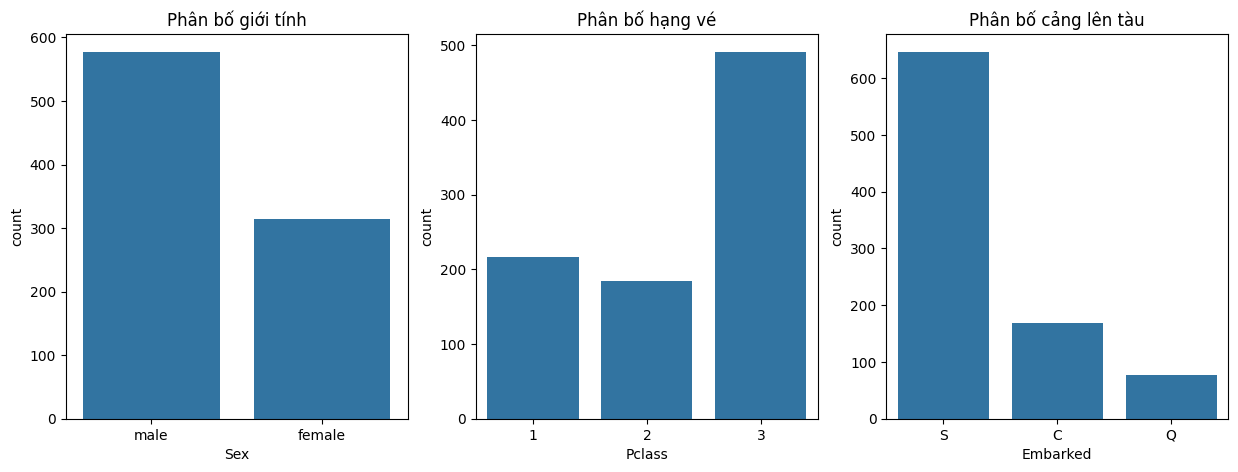

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.countplot(data=df, x="Sex", ax=axes[0])
sns.countplot(data=df, x="Pclass", ax=axes[1])
sns.countplot(data=df, x="Embarked", ax=axes[2])
axes[0].set_title("Phân bố giới tính")
axes[1].set_title("Phân bố hạng vé")
axes[2].set_title("Phân bố cảng lên tàu")
plt.show()

**Nhận xét**
- **Giới tính (Sex):**  
   Biểu đồ cho thấy số lượng **nam giới** chiếm ưu thế rõ rệt so với **nữ giới** trên tàu Titanic.  
   Cụ thể, có khoảng **gần 600 nam** và **hơn 300 nữ**.  
   → Điều này gợi ý rằng tỉ lệ nam giới trong tập dữ liệu cao hơn đáng kể, có thể ảnh hưởng đến tỉ lệ sống sót.

- **Hạng vé (Pclass):**  
   Hành khách **hạng 3** chiếm tỉ lệ lớn nhất, tiếp theo là **hạng 1** và **hạng 2**.  
   → Điều này phản ánh sự chênh lệch xã hội trong hành khách, và đây có thể là yếu tố quan trọng khi phân tích khả năng sống sót (do điều kiện của từng hạng khác nhau).

- **Cảng lên tàu (Embarked):**  
   Đa số hành khách lên tàu tại **cảng S (Southampton)**, tiếp theo là **C (Cherbourg)** và **Q (Queenstown)** với số lượng ít hơn.  
   → Phân bố này cho thấy Southampton là điểm khởi hành chính của tàu Titanic, trong khi hai cảng còn lại chỉ có ít hành khách hơn.


#### 4.2 Biểu đồ phân phối tuổi

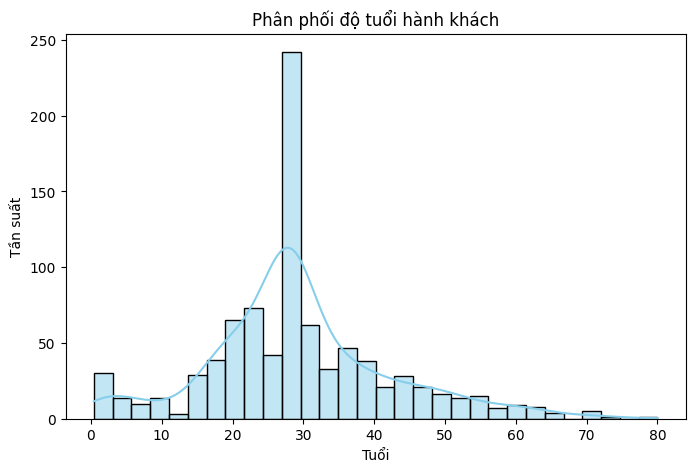

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Age"].dropna(), kde=True, bins=30, color="skyblue")
plt.title("Phân phối độ tuổi hành khách")
plt.xlabel("Tuổi")
plt.ylabel("Tần suất")
plt.show()

**Nhận xét**

Biểu đồ trên thể hiện **phân phối độ tuổi của hành khách trên tàu Titanic**.  

- Phần lớn hành khách tập trung trong độ tuổi **khoảng 20–40 tuổi**, trong đó **đỉnh cao nhất nằm ở khoảng 28–30 tuổi** (phần lớn do ta đặt các giá trị bị thiếu là median).  
- Số lượng hành khách **trẻ em (dưới 10 tuổi)** và **người cao tuổi (trên 60 tuổi)** tương đối ít.  
- Phân phối có dạng **lệch phải (right-skewed)**, nghĩa là có một số ít hành khách ở độ tuổi cao hơn mức trung bình.  

Nhìn chung, phần lớn hành khách là **người trưởng thành trong độ tuổi lao động**, đây là nhóm tuổi có khả năng di chuyển và làm việc cao, phù hợp với bối cảnh lịch sử của chuyến tàu Titanic.


#### 4.3 Biểu đồ Giá vé theo hạng vé

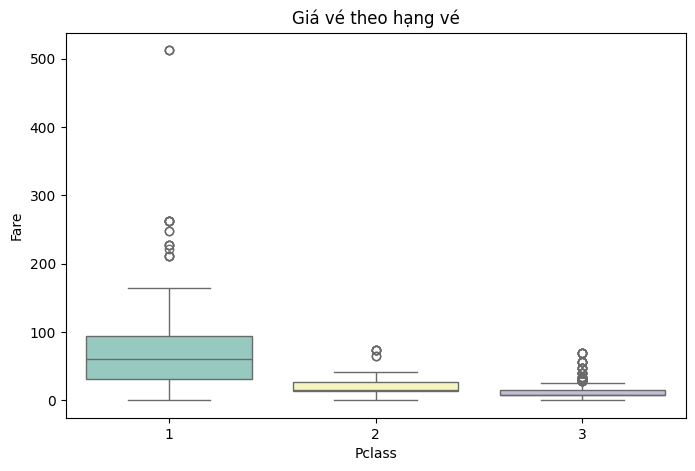

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Pclass", y="Fare", hue="Pclass", palette="Set3", legend=False)
plt.title("Giá vé theo hạng vé")
plt.show()

**Nhận xét**

- **Hạng 1** có mức giá vé **cao nhất** và **dao động lớn**, thể hiện sự khác biệt rõ rệt về điều kiện và tiện nghi.  
  - Một số hành khách hạng 1 có **giá vé vượt quá 500**, được xem là **giá trị ngoại lai** (outliers).  
- **Hạng 2** có giá vé **trung bình**, nằm trong khoảng **10–40 đơn vị tiền tệ**, với ít biến động hơn.  
- **Hạng 3** có giá vé **thấp nhất**, phần lớn hành khách trả **dưới 20 đơn vị tiền tệ**.  

Nhìn chung, **giá vé giảm dần theo thứ tự hạng 1 → hạng 3**, phản ánh rõ ràng **phân tầng xã hội** trên tàu Titanic: hành khách hạng nhất thuộc tầng lớp giàu có, trong khi hành khách hạng ba chủ yếu là người lao động hoặc di cư.


#### 4.4 Biểu đồ Tỷ lệ sống sót tổng thể

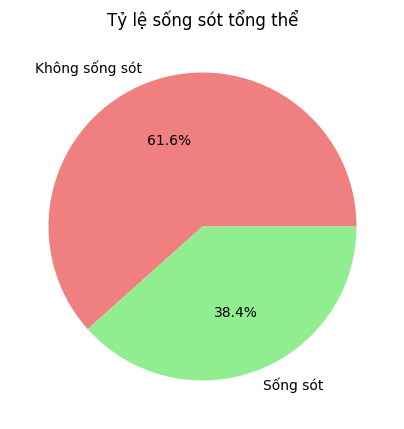

In [14]:
plt.figure(figsize=(5, 5))
df["Survived"].value_counts().plot.pie(
    autopct="%1.1f%%",
    colors=["lightcoral", "lightgreen"],
    labels=["Không sống sót", "Sống sót"],
)
plt.title("Tỷ lệ sống sót tổng thể")
plt.ylabel("")
plt.show()

**Nhận xét**

- **Khoảng 61.6% hành khách không sống sót**, trong khi **38.4% hành khách sống sót**.  
- Tỷ lệ tử vong cao cho thấy **tai nạn xảy ra nghiêm trọng** và **nguồn lực cứu hộ có hạn** (như số lượng xuồng cứu sinh).  
- Sự chênh lệch lớn giữa hai nhóm gợi ý rằng **các yếu tố như giới tính, hạng vé, và độ tuổi** có thể đóng vai trò quan trọng trong khả năng sống sót.  

Kết quả này là cơ sở cho **các phân tích chuyên sâu tiếp theo**, nhằm tìm hiểu **những yếu tố ảnh hưởng đến khả năng sống sót** của hành khách trên tàu Titanic.


#### 4.5 Biểu đồ Tỷ lệ sống sót theo giới tính

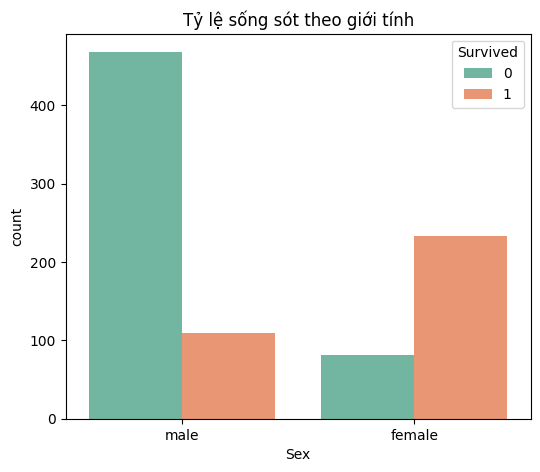

In [15]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="Sex", hue="Survived", palette="Set2")
plt.title("Tỷ lệ sống sót theo giới tính")
plt.show()

**Nhận xét**

- **Nam giới (male)** chiếm phần lớn số hành khách, tuy nhiên **tỷ lệ sống sót rất thấp** — phần lớn đàn ông trên tàu không qua khỏi.  
- **Nữ giới (female)** có **tỷ lệ sống sót cao hơn rõ rệt**, với số người sống sót **vượt xa số không sống sót**.  

Kết quả này phản ánh chính sách **“phụ nữ và trẻ em được ưu tiên lên xuồng cứu sinh trước”** trong quá trình sơ tán. Điều này cho thấy **giới tính là một yếu tố có ảnh hưởng mạnh mẽ đến khả năng sống sót** trong thảm họa Titanic.


#### 4.6 Biểu đồ Tỷ lệ sống sót theo hạng vé

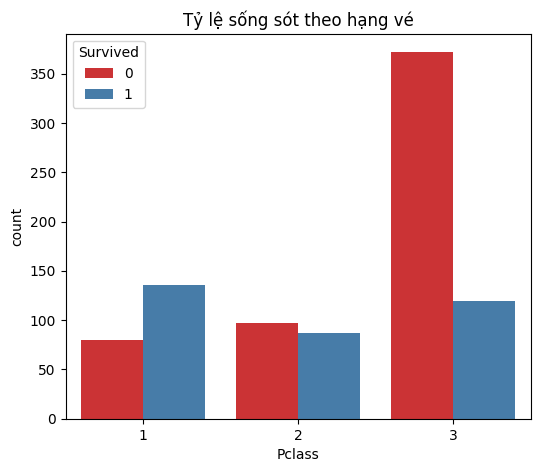

In [16]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="Pclass", hue="Survived", palette="Set1")
plt.title("Tỷ lệ sống sót theo hạng vé")
plt.show()

**Nhận xét**

- **Hạng 1** có **tỷ lệ sống sót cao nhất**, số người sống sót nhiều hơn số tử vong.  
- **Hạng 2** có **tỷ lệ sống sót trung bình**, gần như ngang nhau giữa hai nhóm.  
- **Hạng 3** có **tỷ lệ tử vong rất cao**, với phần lớn hành khách không qua khỏi.  

Kết quả này cho thấy **địa vị xã hội và điều kiện kinh tế (thể hiện qua hạng vé)** có ảnh hưởng lớn đến khả năng sống sót.  Hành khách hạng nhất thường **ở gần khu vực thoát hiểm hơn và được ưu tiên cứu trước**, trong khi hành khách hạng ba **gặp nhiều khó khăn trong việc tiếp cận xuồng cứ**


#### 4.7 Biểu đồ Tỷ lệ sống sót theo cảng lên tàu

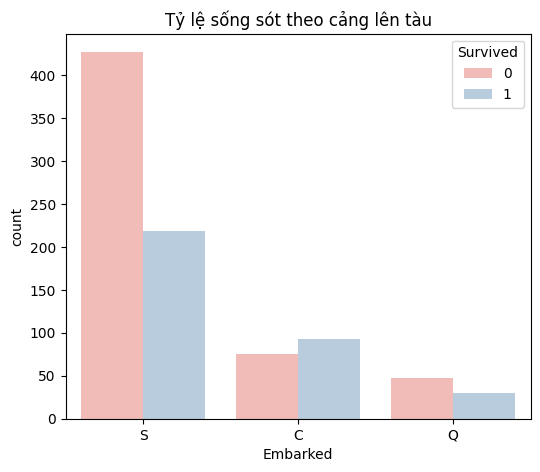

In [17]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="Embarked", hue="Survived", palette="Pastel1")
plt.title("Tỷ lệ sống sót theo cảng lên tàu")
plt.show()


**Nhận xét**

- **Cảng S (Southampton)** có **số lượng hành khách lớn nhất**, nhưng **tỷ lệ tử vong cao hơn đáng kể** so với tỷ lệ sống sót.  
- **Cảng C (Cherbourg)** có **tỷ lệ sống sót cao nhất** trong ba cảng — số người sống sót vượt số người không sống sót.  
- **Cảng Q (Queenstown)** có **ít hành khách nhất** và **tỷ lệ tử vong cao hơn tỷ lệ sống sót**.  

Nhìn chung, sự khác biệt này có thể liên quan đến **điều kiện kinh tế của hành khách tại từng cảng**, vì hành khách lên tàu tại **Cherbourg** thường thuộc **hạng vé cao hơn**, từ đó có **cơ hội sống sót lớn hơn** trong thảm họa.


#### 4.8 Biểu đồ Tỷ lệ sống sót theo danh xưng (Title)

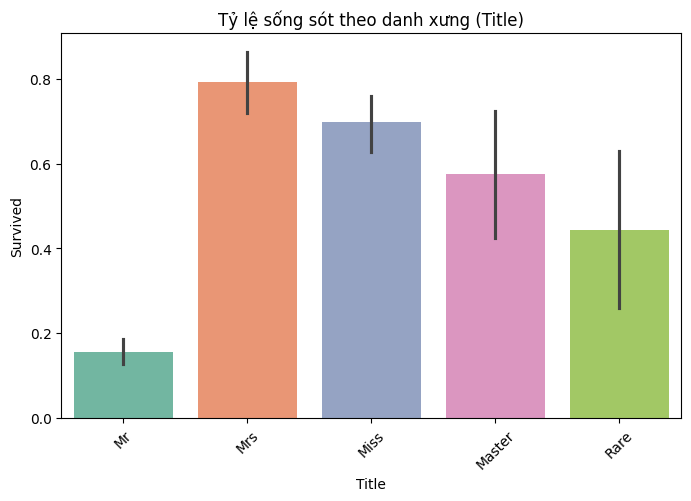

In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Title", y="Survived", hue="Title", palette="Set2", legend=False)
plt.title("Tỷ lệ sống sót theo danh xưng (Title)")
plt.xticks(rotation=45)
plt.show()

**Nhận xét**

- **Mrs (phụ nữ đã kết hôn)** có **tỷ lệ sống sót cao nhất (~80%)**, cho thấy phụ nữ trưởng thành được ưu tiên trong quá trình cứu hộ.  
- **Miss (phụ nữ chưa kết hôn)** cũng có **tỷ lệ sống sót cao (~70%)**, tương tự như nhóm *Mrs*.  
- **Master (trẻ em nam)** có **tỷ lệ sống sót trung bình (~58%)**, phản ánh sự ưu tiên cứu trẻ em.  
- **Mr (đàn ông trưởng thành)** có **tỷ lệ sống sót thấp nhất (~15%)**, phù hợp với giả thuyết “phụ nữ và trẻ em được cứu trước”.  
- **Rare (các danh xưng hiếm, như quý tộc hoặc sĩ quan)** có **tỷ lệ sống sót biến động (~45%)**, do số lượng ít và hoàn cảnh khác biệt.  

Kết luận: **Danh xưng là đặc trưng quan trọng** giúp mô hình nhận diện khả năng sống sót, vì nó phản ánh **giới tính, độ tuổi và địa vị xã hội** của hành khách.


#### 4.9 Biểu đồ Tỷ lệ sống sót theo nhóm tuổi

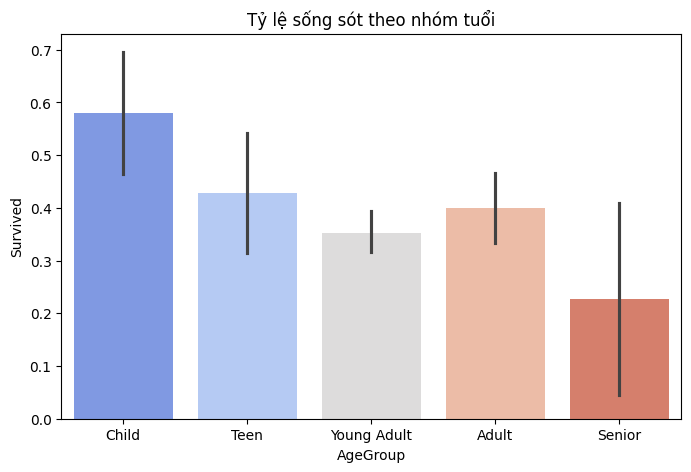

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="AgeGroup",
    y="Survived",
    palette="coolwarm",
    hue="AgeGroup",
    legend=False,
)
plt.title("Tỷ lệ sống sót theo nhóm tuổi")
plt.show()

**Nhận xét**

- **Child (trẻ em)** có **tỷ lệ sống sót cao nhất (~58%)**, cho thấy **trẻ em được ưu tiên cứu trước** trong quá trình sơ tán.  
- **Teen (thiếu niên)** có **tỷ lệ sống sót trung bình (~43%)**, thấp hơn trẻ em nhưng vẫn cao hơn người lớn.  
- **Young Adult (thanh niên)** có **tỷ lệ sống sót thấp nhất trong nhóm người trẻ (~35%)**, có thể do phần lớn là **nam giới trong độ tuổi lao động**.  
- **Adult (người trưởng thành)** có **tỷ lệ sống sót khoảng 40%**, cho thấy một phần phụ nữ trưởng thành được cứu, nhưng nam giới thì không.  
- **Senior (người cao tuổi)** có **tỷ lệ sống sót thấp nhất (~23%)**, phản ánh khả năng **di chuyển chậm và ít được ưu tiên**.  

**Kết luận:** Nhóm tuổi có ảnh hưởng đáng kể đến khả năng sống sót. **Trẻ em và thiếu niên có tỷ lệ sống cao hơn**, trong khi **người lớn tuổi và thanh niên** (đặc biệt là nam giới) có khả năng sống sót thấp hơn.


#### 4.10 Biểu đồ Tỷ lệ sống sót theo quy mô gia đình

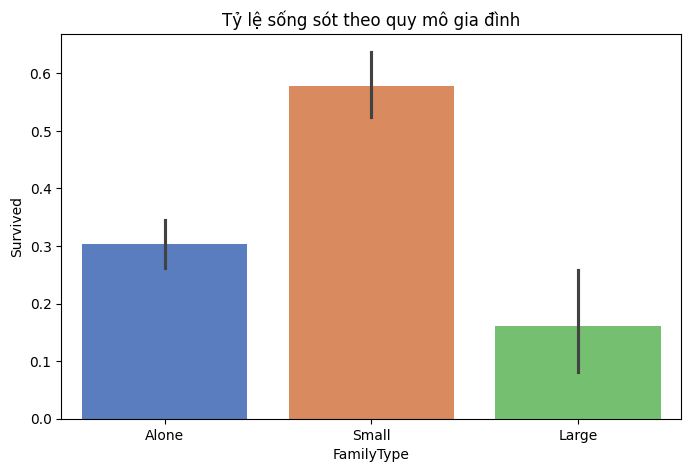

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="FamilyType",
    y="Survived",
    palette="muted",
    hue="FamilyType",
    legend=False,
)
plt.title("Tỷ lệ sống sót theo quy mô gia đình")
plt.show()

**Nhận xét**

- **Gia đình nhỏ (Small)** có **tỷ lệ sống sót cao nhất** (~58%), cho thấy việc đi cùng một số ít thành viên gia đình **tăng khả năng hỗ trợ và phối hợp** trong tình huống khẩn cấp.

- **Đi một mình (Alone)** có **tỷ lệ sống sót trung bình** (~31%), thấp hơn đáng kể so với gia đình nhỏ nhưng vẫn cao hơn gia đình lớn, có **tính linh hoạt cao** nhưng thiếu sự hỗ trợ.

- **Gia đình lớn (Large)** có **tỷ lệ sống sót thấp nhất** (~17%), cho thấy việc đi cùng nhiều thành viên gia đình **gây khó khăn trong di chuyển và thoát hiểm**, phần lớn phải **chăm sóc nhiều người**, đặc biệt là trẻ em và người già, làm **chậm quá trình thoát hiểm**.

Độ biến thiên lớn (đặc biệt ở nhóm gia đình nhỏ và lớn) cho thấy **có sự khác biệt đáng kể** giữa các trường hợp, phụ thuộc vào yếu tố như vị trí cabin, hạng vé và cấu trúc gia đình cụ thể.

#### 4.11 Biểu đồ Tỷ lệ sống sót theo mức giá vé

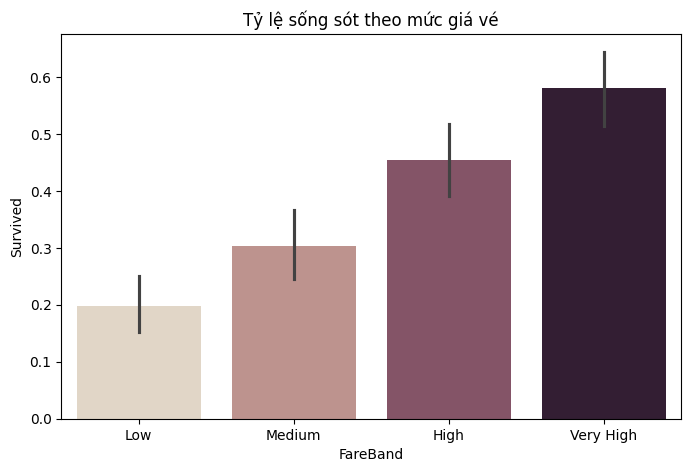

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="FareBand",
    y="Survived",
    palette="ch:s=.25",
    hue="FareBand",
    legend=False,
)
plt.title("Tỷ lệ sống sót theo mức giá vé")
plt.show()

**Nhận xét**

- **Mức giá rất cao (Very High)** có **tỷ lệ sống sót cao nhất** (~58%), cho thấy hành khách trả giá vé cao nhất có **lợi thế lớn nhất** trong việc sống sót.

- **Mức giá cao (High)** có **tỷ lệ sống sót khá** (~46%), thấp hơn nhóm Very High nhưng vẫn ở mức trung bình khá.

- **Mức giá trung bình (Medium)** có **tỷ lệ sống sót thấp hơn** (~31%), cho thấy sự chênh lệch rõ rệt so với nhóm giá cao.

- **Mức giá thấp (Low)** có **tỷ lệ sống sót thấp nhất** (~20%), phản ánh điều kiện bất lợi của hành khách nghèo.

Kết quả này cho thấy **mức giá vé có tương quan mạnh với khả năng sống sót**:

- Hành khách trả giá vé cao thường **ở cabin tầng trên, gần khu vực thoát hiểm** và được **ưu tiên tiếp cận xuồng cứu sinh**.
- Hành khách trả giá vé thấp thường **ở tầng dưới cùng**, phải **di chuyển xa hơn để thoát hiểm** và gặp nhiều rào cản vật lý.
- Yếu tố **kinh tế-xã hội** đóng vai trò quyết định trong cơ hội sinh tồn.

Độ biến thiên trong các nhóm (đặc biệt ở Very High) cho thấy **vẫn có sự khác biệt cá nhân** phụ thuộc vào yếu tố như giới tính, tuổi tác và vị trí cụ thể trên tàu.

#### 4.12 Biểu đồ Tỷ lệ sống sót theo khu vực khoang tàu

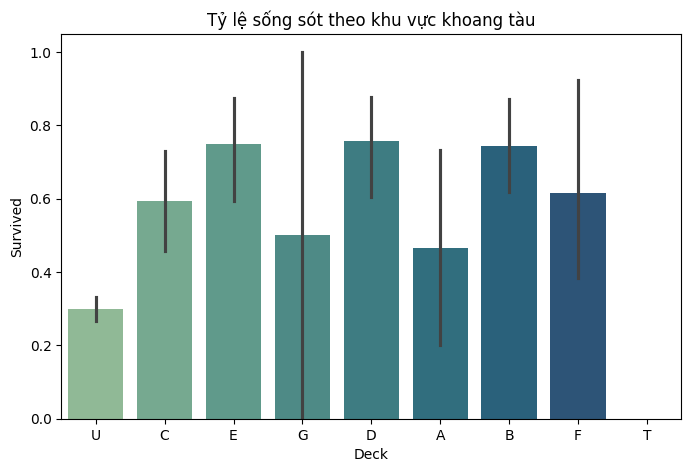

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Deck", y="Survived", palette="crest", hue="Deck", legend=False)
plt.title("Tỷ lệ sống sót theo khu vực khoang tàu")
plt.show()


**Nhận xét**

- **Khoang E** có **tỷ lệ sống sót cao nhất** (~75%), cho thấy đây là **vị trí thuận lợi** cho việc thoát hiểm.

- **Khoang D** và **Khoang B** có **tỷ lệ sống sót rất cao** (~76% và ~74%), thuộc nhóm **các tầng trên** với khả năng tiếp cận xuồng cứu sinh tốt.

- **Khoang F** có **tỷ lệ sống sót khá** (~62%), thấp hơn các khoang trên nhưng vẫn ở mức trung bình.

- **Khoang C** có **tỷ lệ sống sót trung bình** (~60%), với độ biến thiên lớn cho thấy sự khác biệt đáng kể giữa các hành khách.

- **Khoang G** có **tỷ lệ sống sót thấp** (~50%), phản ánh vị trí **không thuận lợi** hơn cho thoát hiểm.

- **Khoang A** có **tỷ lệ sống sót thấp** (~47%), mặc dù là khoang cao cấp nhưng có thể do **số lượng mẫu ít** hoặc yếu tố khác.

- **Khoang U** (Unknown - không xác định) có **tỷ lệ sống sót thấp nhất** (~30%), cho thấy hành khách **không có thông tin cabin rõ ràng** thường ở điều kiện bất lợi.

Kết quả này cho thấy **vị trí khoang tàu** có ảnh hưởng quan trọng đến khả năng sống sót:

- Các khoang **tầng trên và giữa tàu** (B, D, E) có lợi thế về **khoảng cách đến xuồng cứu sinh**.
- Các khoang **tầng dưới** (G) và **không xác định** (U) gặp nhiều khó khăn hơn trong việc thoát hiểm.
- Độ biến thiên lớn ở hầu hết các khoang cho thấy **yếu tố cá nhân** (giới tính, tuổi tác, hạng vé) vẫn đóng vai trò quan trọng. Phân tích biểu đồ tỷ lệ sống sót theo khu vực khoang tàu

#### 4.13 Biểu đồ Ma trận tương quan giữa các biến số

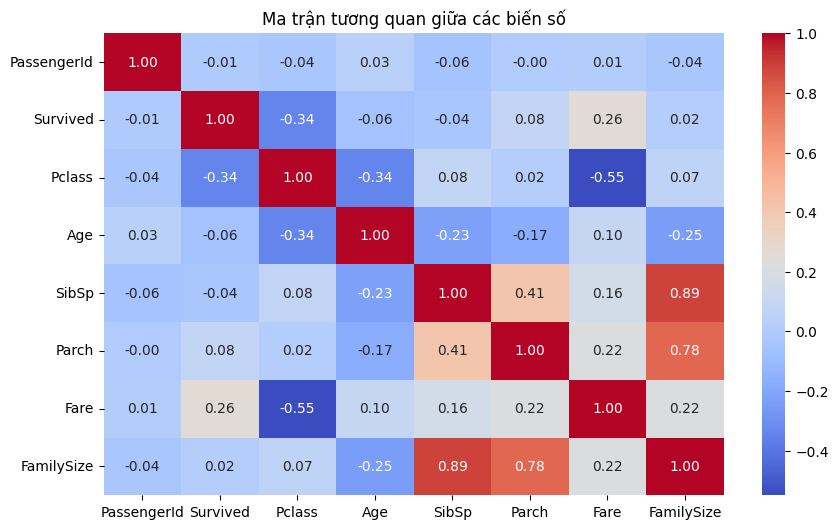

In [23]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan giữa các biến số")
plt.show()

**Nhận xét**

- Tương quan mạnh (|r| > 0.5):
    - **FamilySize ↔ SibSp** (0.89) và **FamilySize ↔ Parch** (0.78): Quy mô gia đình tương quan rất mạnh với số người thân đi cùng.
    - **Fare ↔ Pclass** (-0.55): Giá vé tương quan nghịch với hạng vé - hạng càng cao thì giá càng đắt.

- Tương quan trung bình (0.2 < |r| < 0.5): 
    - **Pclass ↔ Survived** (-0.34): Hạng vé cao có tỷ lệ sống sót cao hơn.
    - **Pclass ↔ Age** (-0.34): Hành khách hạng cao có xu hướng trẻ hơn.
    - **Survived ↔ Fare** (0.26): Giá vé cao có tỷ lệ sống sót cao hơn.

- Tương quan yếu:
    - **Age**, **SibSp**, **Parch** có tương quan yếu với **Survived**.
    - **PassengerId** không có ý nghĩa tương quan (chỉ là mã định danh).

**Yếu tố kinh tế-xã hội** (Pclass, Fare) có ảnh hưởng rõ rệt đến khả năng sống sót, trong khi **các biến gia đình** có tương quan chặt với nhau nhưng ảnh hưởng không trực tiếp mạnh đến tỷ lệ sống sót.

#### 4.14 Biểu đồ Phân phối tuổi theo giới tính và tình trạng sống sót

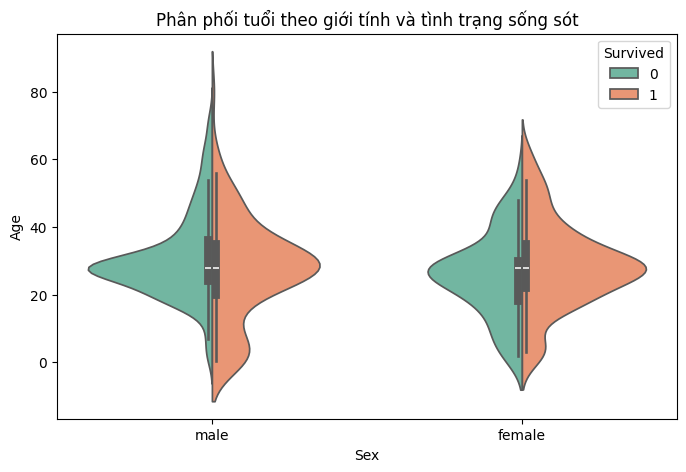

In [24]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="Sex", y="Age", hue="Survived", split=True, palette="Set2")
plt.title("Phân phối tuổi theo giới tính và tình trạng sống sót")
plt.show()


**Nhận xét**

- Nam giới (Male):
    - **Không sống sót (0 - màu xanh)**: Phân phối rộng từ trẻ em đến người cao tuổi, tập trung chủ yếu ở độ tuổi **20-40**, với đỉnh cao nhất khoảng **25-30 tuổi**.
    - **Sống sót (1 - màu cam)**: Phân phối tương tự nhưng **mật độ thấp hơn** đáng kể, cho thấy **tỷ lệ tử vong cao** ở nam giới.
    - Độ tuổi trung vị (đường trắng trong boxplot) của cả hai nhóm gần như **tương đương** (~28-30 tuổi).

- Nữ giới (Female):
    - **Không sống sót (0 - màu xanh)**: Phân phối **hẹp hơn** so với nam giới, tập trung chủ yếu ở độ tuổi **20-40**.
    - **Sống sót (1 - màu cam)**: Phân phối **rộng và dày hơn**, cho thấy **tỷ lệ sống sót cao** ở nữ giới ở hầu hết các lứa tuổi.
    - Độ tuổi trung vị của cả hai nhóm cũng **tương đương** (~28-30 tuổi).

- So sánh giữa nam và nữ:

    - **Nữ giới có tỷ lệ sống sót cao hơn rõ rệt** so với nam giới, phản ánh nguyên tắc **"phụ nữ và trẻ em trước"** trong cứu hộ.
    - Ở **cả hai giới**, phân phối tuổi của nhóm sống sót và không sống sót có độ tuổi trung vị tương tự, cho thấy **tuổi tác không phải yếu tố quyết định** chính trong khả năng sống sót khi so sánh với giới tính.
    - **Trẻ em** (dưới 10 tuổi) có mật độ cao ở nhóm sống sót cả nam và nữ, thể hiện sự ưu tiên cứu trẻ em.

**Giới tính** là yếu tố quan trọng hơn **tuổi tác** trong việc quyết định khả năng sống sót, với nữ giới được ưu tiên rõ rệt trong quá trình cứu hộ.

#### 4.15 Biểu đồ Phân phối độ tuổi theo giới tính và trạng thái sống sót

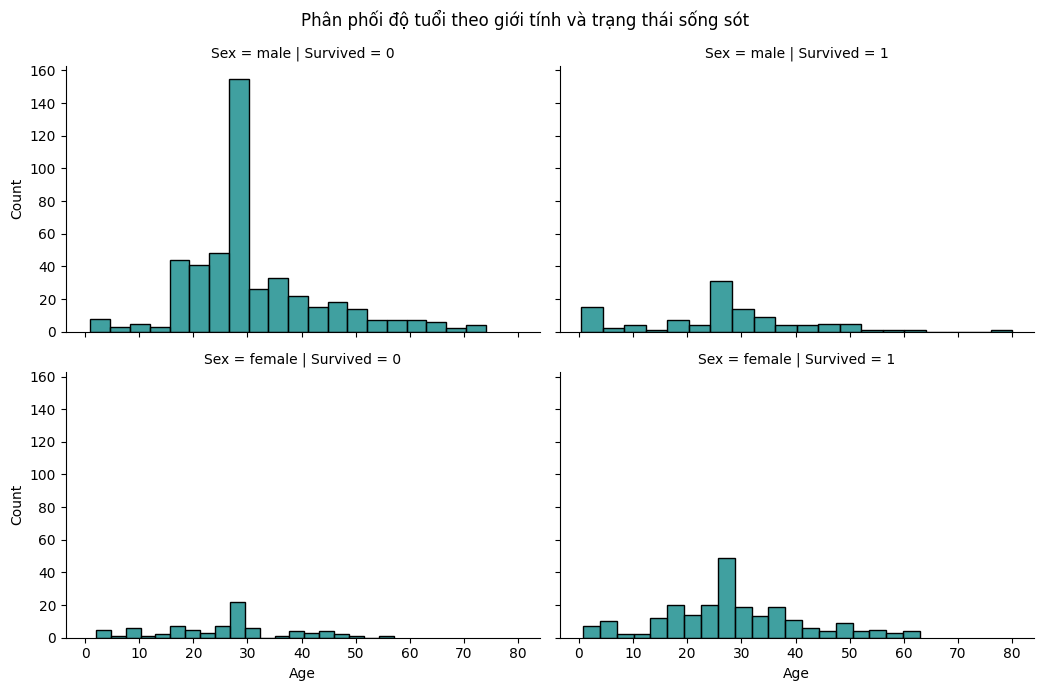

In [25]:
g = sns.FacetGrid(df, col="Survived", row="Sex", height=3.5, aspect=1.5)
g.map_dataframe(sns.histplot, x="Age", bins=20, color="teal")
g.add_legend()
plt.subplots_adjust(top=0.9)
g.figure.suptitle("Phân phối độ tuổi theo giới tính và trạng thái sống sót")
plt.show()

**Nhận xét**

- Nam giới (Male):

    - Không sống sót (Survived = 0):
        - Có **số lượng rất lớn** (~155 người) tập trung ở độ tuổi **20-30**, đặc biệt là khoảng **25 tuổi**.
        - Phân phối rộng từ trẻ em đến người cao tuổi (0-80 tuổi).
        - Số lượng giảm dần ở các độ tuổi cao hơn.

- Sống sót (Survived = 1):
    - Số lượng **ít hơn đáng kể** so với nhóm không sống sót.
    - Đỉnh cao nhất ở độ tuổi **25-30** (~30 người).
    - Phân phối tương đối đồng đều ở các lứa tuổi, cho thấy nam giới ở mọi lứa tuổi đều có **tỷ lệ sống sót thấp**.

- Nữ giới (Female):

    - Không sống sót (Survived = 0):
        - Số lượng **thấp hơn nhiều** so với nam giới không sống sót.
        - Đỉnh cao nhất ở độ tuổi **25-30** (~25 người).
        - Phân phối tương đối phẳng, cho thấy nữ giới ở hầu hết các lứa tuổi có **tỷ lệ tử vong thấp**.

- Sống sót (Survived = 1):
    - Số lượng **cao hơn đáng kể** so với nhóm không sống sót.
    - Đỉnh cao nhất ở độ tuổi **25-30** (~50 người).
    - Phân phối rộng từ trẻ em đến người trung niên, cho thấy nữ giới được **ưu tiên cứu hộ mạnh mẽ**.

- So sánh và kết luận

    - **Nam giới có tỷ lệ tử vong áp đảo**: Số nam giới không sống sót (~155 ở đỉnh) cao hơn gấp **nhiều lần** so với số sống sót (~30).

    - **Nữ giới có tỷ lệ sống sót cao**: Số nữ giới sống sót (~50 ở đỉnh) cao hơn số không sống sót (~25), thể hiện rõ nguyên tắc **"phụ nữ và trẻ em trước"**.

    - **Độ tuổi 20-30 chiếm đa số**: Cả nam và nữ đều có số lượng lớn nhất ở nhóm tuổi này, phản ánh **cơ cấu hành khách** trên tàu.

    - **Giới tính quan trọng hơn tuổi tác**: Sự chênh lệch giữa nam và nữ trong tỷ lệ sống sót rõ ràng hơn nhiều so với sự khác biệt theo độ tuổi.

#### 4.16 Biểu đồ Phân bố danh xưng (Title) theo giới tính

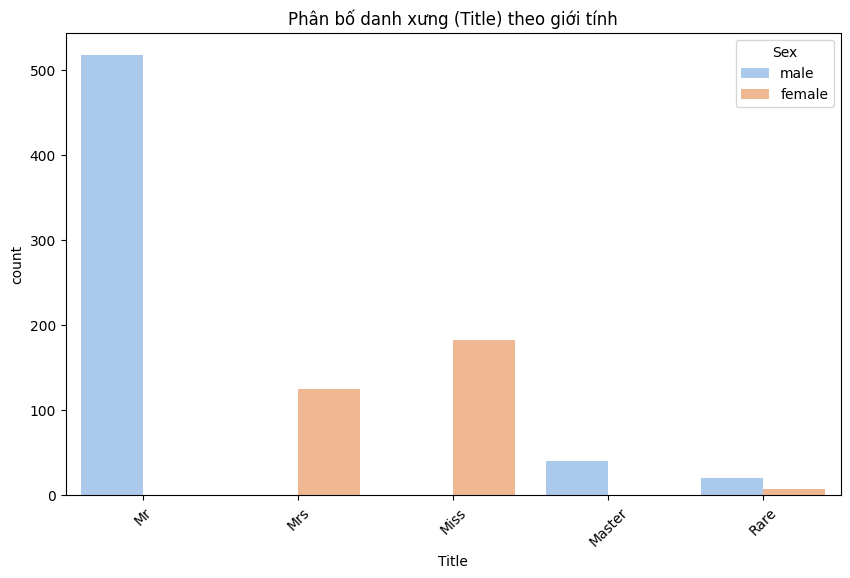

In [26]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Title", hue="Sex", palette="pastel")
plt.title("Phân bố danh xưng (Title) theo giới tính")
plt.xticks(rotation=45)
plt.show()


**Nhận xét**

- **Mr (Ông)**: Số lượng **áp đảo** (~520 nam giới), chiếm đa số hành khách trên tàu.

- **Miss (Cô)**: Khoảng **180 nữ giới**, đại diện cho phụ nữ chưa kết hôn/trẻ em nữ.

- **Mrs (Bà)**: Khoảng **125 nữ giới**, đại diện cho phụ nữ đã kết hôn.

- **Master (Cậu bé)**: Khoảng **40 nam giới**, danh xưng dành cho trẻ em nam.

- **Rare (Hiếm)**: Rất ít (~20 người), bao gồm danh xưng đặc biệt như Dr, Rev, Col, Lady, v.v.

**Nam giới trưởng thành** (Mr) chiếm đa số trên tàu, tiếp theo là **phụ nữ** (Miss, Mrs), và **ít trẻ em** (Master). Cơ cấu này ảnh hưởng trực tiếp đến tỷ lệ sống sót do nguyên tắc **"phụ nữ và trẻ em trước"**.

## III. Áp dụng các mô hình máy học

### 1. Giới thiệu

Bốn mô hình được lựa chọn bao gồm:

*  **Logistic Regression** – mô hình tuyến tính cơ bản, giúp thiết lập baseline ban đầu.
*  **Random Forest Classifier** – mô hình cây rừng ngẫu nhiên, mạnh trong việc xử lý dữ liệu phi tuyến và tương tác giữa các biến.
*  **Gradient Boosting Classifier** – mô hình tăng cường dần (boosting), giúp cải thiện hiệu năng dự đoán thông qua việc kết hợp nhiều cây yếu.
* **Support Vector Machine (SVM)** – mô hình phân tách tối ưu bằng siêu phẳng, thích hợp cho các bài toán phân loại nhị phân phức tạp.

Tất cả mô hình đều được thiết lập với **random_state = 42** để đảm bảo tính tái lập kết quả.
Quy trình này giúp so sánh hiệu quả giữa các thuật toán khác nhau trong cùng một điều kiện xử lý dữ liệu.

### 2. Áp dụng các mô hình

#### 2.1 Chạy các mô hình

In [27]:
# ======= 1. Select features and target =======
# Choose a reasonable set of features
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'Deck', 'FamilySize', 'FareBand']
target = 'Survived'

X = df[features]
y = df[target]

# ======= 2. Train/test split =======
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# ======= 3. Preprocessing pipelines =======
# Numeric features
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'FamilySize']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical features
categorical_features = ['Sex', 'Embarked', 'Title', 'Deck', 'FareBand']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# ======= 4. Define models (pipelines) =======
models = {
    'LogisticRegression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'RandomForest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    'GradientBoosting': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clf', GradientBoostingClassifier(n_estimators=200, random_state=42))
    ]),
    'SVM': Pipeline(steps=[
        ('preprocessor', preprocessor),
        # probability=True needed for roc_auc_score
        ('clf', SVC(kernel='rbf', probability=True, random_state=42))
    ])
}

# ======= 5. Train & Evaluate =======
results = []

for name, pipeline in models.items():
    print(f"Training {name} ...")
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    # For roc_auc, get probabilities if available; otherwise use decision_function for SVM (we set probability=True so use predict_proba)
    if hasattr(pipeline.named_steps['clf'], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        # fallback (shouldn't occur with current models)
        try:
            y_scores = pipeline.decision_function(X_test)
            roc_auc = roc_auc_score(y_test, y_scores)
        except Exception:
            roc_auc = np.nan

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'model': name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc_auc
    })

results_df = pd.DataFrame(results).set_index('model')
print("\nEvaluation results (test set):")
print(results_df)

Training LogisticRegression ...
Training RandomForest ...
Training GradientBoosting ...
Training SVM ...

Evaluation results (test set):
                    accuracy  precision    recall        f1   roc_auc
model                                                                
LogisticRegression  0.824627   0.769231  0.776699  0.772947  0.873698
RandomForest        0.798507   0.775281  0.669903  0.718750  0.838247
GradientBoosting    0.794776   0.779070  0.650485  0.708995  0.842689
SVM                 0.828358   0.787879  0.757282  0.772277  0.865578


#### 2.2 Trực quan hóa kết quả mô hình

<Figure size 1000x600 with 0 Axes>

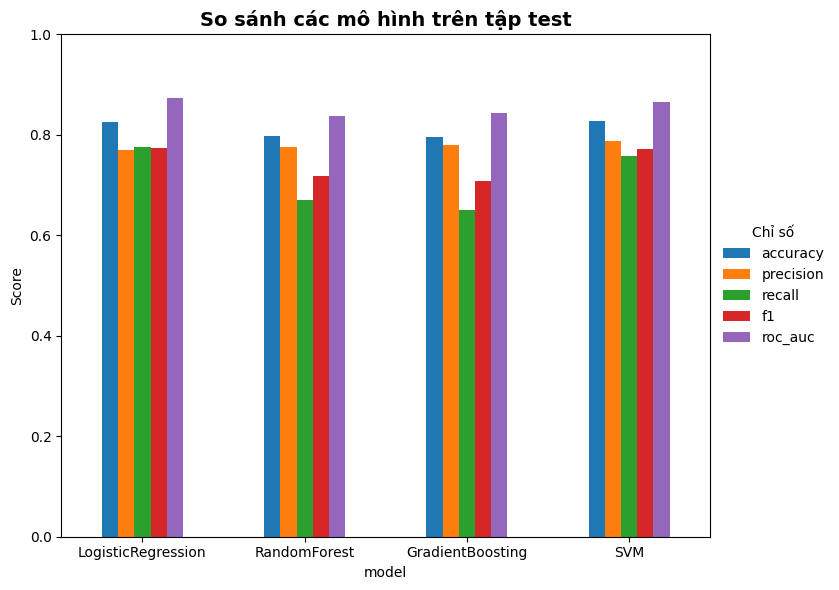

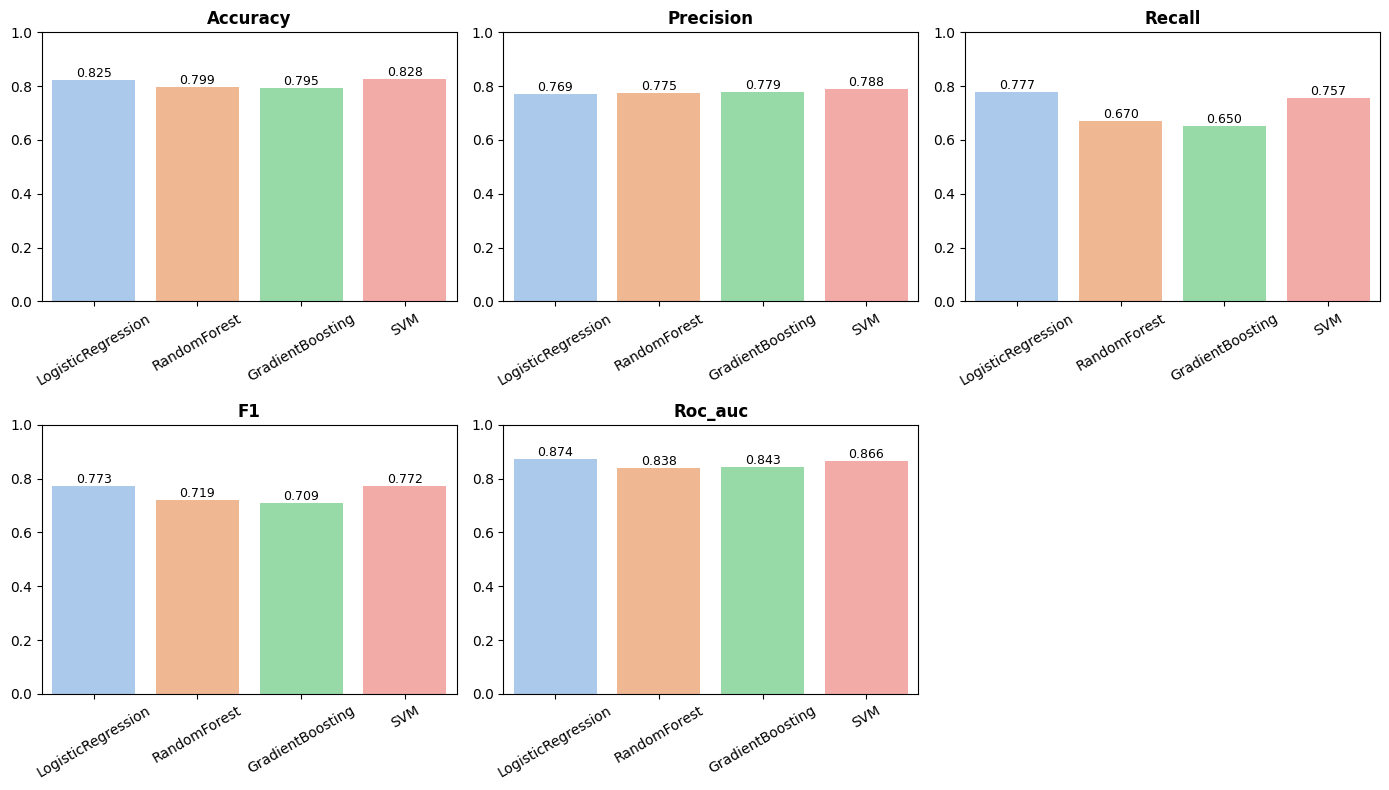

In [28]:
# ======= 6. Draw total chart comparison model =======
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

plt.figure(figsize=(10,6))
ax = results_df[metrics].plot(kind='bar', rot=0, figsize=(10,6))
plt.title("So sánh các mô hình trên tập test", fontsize=14, weight='bold')
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

#  Legend sang bên phải
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False, title="Chỉ số")
plt.tight_layout(rect=[0, 0, 0.85, 1])  # chừa chỗ bên phải cho legend
plt.show()


# ======= 7. Draw Individual metric charts =======
fig, axes = plt.subplots(2, 3, figsize=(14,8))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.barplot(x=results_df.index, y=results_df[metric].values, ax=ax, palette="pastel", hue=results_df.index, legend=False)
    ax.set_ylim(0,1)
    ax.set_title(metric.capitalize(), fontsize=12, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30)  # 🔹 chữ nghiêng để dễ đọc
    for p, val in zip(ax.patches, results_df[metric].values):
        ax.annotate(f"{val:.3f}", 
                    (p.get_x() + p.get_width()/2., p.get_height()), 
                    ha='center', va='bottom', fontsize=9)

# Xóa subplot thừa nếu có
if len(metrics) < len(axes):
    for j in range(len(metrics), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Nhận xét**

* **SVM** đạt **Accuracy cao nhất (≈0.83)** và F1 cân bằng tốt.
* **Logistic Regression** có **Recall và ROC-AUC cao nhất**, dự đoán người sống sót tốt.
* **Random Forest** và **Gradient Boosting** kém hơn, dễ overfit và bỏ sót mẫu sống sót.

**Kết luận:**

- **SVM** và **Logistic Regression** là hai mô hình hiệu quả và ổn định nhất cho bài toán Titanic.
- Ta chọn mô hình **SVM** vì từ biểu đồ so sánh hiệu suất, SVM đạt độ chính xác (Accuracy) và F1-score cao nhất, đồng thời duy trì ROC-AUC ổn định. Mô hình này cân bằng tốt giữa khả năng nhận diện hành khách sống sót và giảm thiểu lỗi phân loại.


### 3. Áp dụng mô hình tốt nhất và lưu kết quả

In [ ]:
# Đọc tập test
df_test = pd.read_csv("./data/test.csv")
data_pipeline(df_test)

# Lấy riêng mô hình SVM từ dictionary
svm_model = models['SVM']

# Huấn luyện mô hình
svm_model.fit(X_train, y_train)

# Dự đoán
y_pred = svm_model.predict(X_test)

# Đánh giá độ chính xác
acc = accuracy_score(y_test, y_pred)
print("SVM Accuracy:", round(acc, 4))

X_test = df_test[numeric_features + categorical_features]
test_pred = svm_model.predict(X_test)

# Xuất file kết quả
submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': test_pred
})

submission.head()


No duplicated rows found.
SVM Accuracy: 0.8284


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [30]:
submission.to_csv('data/svm_submission.csv', index=False)
print("Đã tạo file dự đoán: svm_submission.csv")

Đã tạo file dự đoán: svm_submission.csv


# Kết thúc